In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import * 
from Triangle_BBH.Fisher import *

# import multiprocessing
# if __name__=='__main__':
#     multiprocessing.set_start_method("fork")
    
import bilby 

# np.random.seed(114517)
# xp.random.seed(114514)

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


has cupy
has cupy
has BBHx waveform


In [2]:
t_start = 0. * DAY # start time in s
Tobs = 90. * DAY # data length in s 
t_end = t_start + Tobs # end time in s 
dt = 10. # time cadance in s 
fsample = 1. / dt # sampling rate in Hz 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
for i in range(1, 50): 
    mask_idx = np.where(np.abs(data_frequencies_full - i*0.025)<i*3e-4)[0]
    mask[mask_idx] = False 

# remove the frequencies below Taiji sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape, data_frequencies_full.shape 

((379392,), (388801,))

In [3]:
PSDfunc = TDIPSDs()
data_psd = PSDfunc.PSD_A2(data_frequencies)

In [4]:
# the path of Taiji orbit 
orbit = Orbit(
    OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB", 
    ) 


WFG = WaveformGeneratorFRef(
    # mode="primary", 
    mode="full", 
)

FDTDI = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG, 
)

# response settings 
response_kwargs_interp = dict(
    fmin=1e-5, # used to calculate freq grid
    fmax=1e-1, # used to calculate freq grid
    fref=1e-3, 
    Nfreqs=1024, # used to calculate freq grid
    # modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tref_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method='cubic',
)

response_kwargs_direct = dict(
    fref=1e-3, 
    # modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tref_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method=None,
)

In [5]:
lgMc_prior = [5.5, 6.5]
q_prior = [0.1, 1]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [(t_start + 0.3 * Tobs) / DAY, (t_end - 0.3 * Tobs) / DAY] # ensure the inclusion of long enough GW waveform 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

lgdl_prior = [4., 5.]

mbhb_parameters = {
    'chirp_mass': np.power(10., np.random.uniform(lgMc_prior[0], lgMc_prior[1])), 
    'mass_ratio': np.random.uniform(q_prior[0], q_prior[1]), 
    'spin_1z': np.random.uniform(s1_prior[0], s1_prior[1]),
    'spin_2z': np.random.uniform(s2_prior[0], s2_prior[1]),
    'reference_time': np.random.uniform(tc_prior[0], tc_prior[1]), 
    'reference_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(lgdl_prior[0], lgdl_prior[1])), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(lam_prior[0], lam_prior[1]), # [rad]
    'latitude': np.arcsin(np.random.uniform(sinbeta_prior[0], sinbeta_prior[1])), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }
mbhb_parameters

{'chirp_mass': 827693.2821010326,
 'mass_ratio': 0.6060083963754411,
 'spin_1z': -0.1447564612873118,
 'spin_2z': 0.4923926864730753,
 'reference_time': 58.927959071370836,
 'reference_phase': 2.1563629722527997,
 'luminosity_distance': 22016.264842325963,
 'inclination': 1.9340646499796517,
 'longitude': 3.279277442759269,
 'latitude': 0.9176152704924524,
 'psi': 1.988850127130235}

In [6]:
wf_channels1 = FDTDI.Response(
    mbhb_parameters, 
    data_frequencies, 
    **response_kwargs_interp, 
)

wf_channels2 = FDTDI.Response(
    mbhb_parameters, 
    data_frequencies, 
    **response_kwargs_direct, 
)

wf_channels1.shape, wf_channels2.shape 

((3, 379392), (3, 379392))

In [7]:
print("SNR (interpolated)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels1[:2])**2 / data_psd)))
print("SNR (direct)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels2[:2])**2 / data_psd)))
print("SNR (residual)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels1[:2] - wf_channels2[:2])**2 / data_psd)))

SNR (interpolated) 1291.013806330784
SNR (direct) 1291.015850194603
SNR (residual) 0.1572059079403514


(1e-25, 3.4579502709689575e-18)

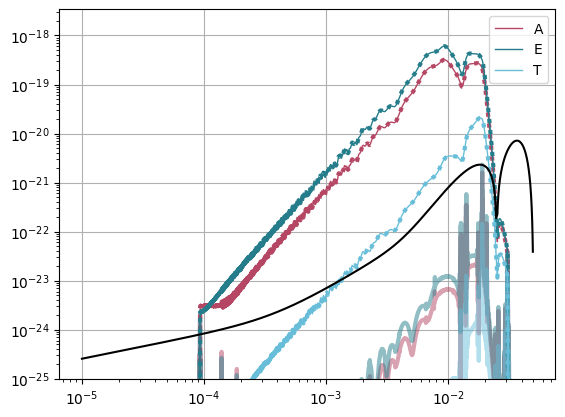

In [8]:
ch_names = ["A", "E", "T"]
ch_colors = [RED, GREEN1, BLUE]
psdfunc = TDIPSDs()
for i in range(3):
    plt.loglog(data_frequencies, np.abs(wf_channels1[i]) * 2. * data_frequencies, color=ch_colors[i], label=ch_names[i], linestyle="-", linewidth=1)
    plt.loglog(data_frequencies, np.abs(wf_channels2[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle=":", linewidth=3)
    plt.loglog(data_frequencies, np.abs(wf_channels1[i] - wf_channels2[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle="-", alpha=0.5, linewidth=3)
plt.loglog(data_frequencies, np.sqrt(psdfunc.PSD_X2(data_frequencies) * data_frequencies), color="k")
plt.legend()
plt.grid()
plt.ylim(1e-25,)
# plt.xlim(5e-5, 0.1)

In [9]:
wf_channels_full1 = np.nan_to_num(FDTDI.Response(
    mbhb_parameters, 
    data_frequencies_full[1:], 
    **response_kwargs_interp, 
)[0], nan=0.)
wf_channels_full1 = np.concatenate(([0.,], wf_channels_full1), axis=0)

wf_channels_full2 = np.nan_to_num(FDTDI.Response(
    mbhb_parameters, 
    data_frequencies_full[1:], 
    **response_kwargs_direct, 
)[0], nan=0.)
wf_channels_full2 = np.concatenate(([0.,], wf_channels_full2), axis=0)

wf_td1 = np.fft.irfft(wf_channels_full1)
wf_td2 = np.fft.irfft(wf_channels_full2)


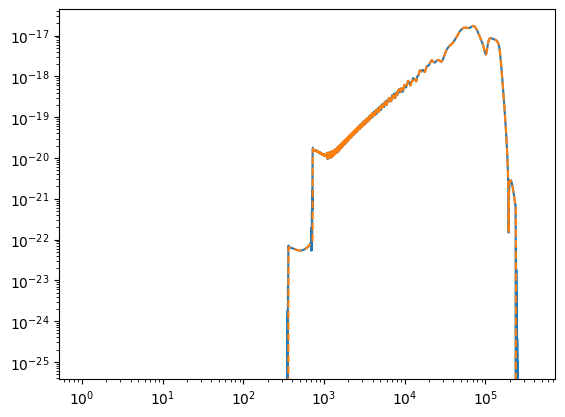

In [10]:
plt.loglog(np.abs(wf_channels_full1))
plt.loglog(np.abs(wf_channels_full2), linestyle="--")

(5088900.0, 5108900.0)

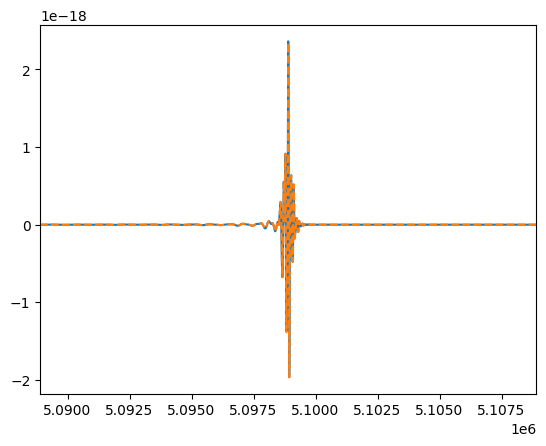

In [11]:
plot_times = np.arange(int(Tobs/dt))*dt
peak_idx = np.argmax(np.abs(wf_td1))
peak_time = plot_times[peak_idx]
plt.plot(plot_times, wf_td1)
plt.plot(plot_times, wf_td2, linestyle="--")
plt.xlim(peak_time-10000, peak_time+10000)

In [12]:
peak_time/DAY, mbhb_parameters["reference_time"]

(59.0150462962963, 58.927959071370836)

In [13]:
Ntest = 101 
test_param_dev = np.linspace(-100, 100, Ntest)
ll_int = [] 
ll_dir = [] 
for itest in tqdm(range(Ntest)): 
    test_params = mbhb_parameters.copy() 
    test_params["chirp_mass"] += test_param_dev[itest]

    tmp_channels1 = FDTDI.Response(
        test_params, 
        data_frequencies, 
        **response_kwargs_interp, 
    )
    tmp_channels2 = FDTDI.Response(
        test_params, 
        data_frequencies, 
        **response_kwargs_direct, 
    )

    res1 = (tmp_channels1 - wf_channels1)[:2]
    res2 = (tmp_channels2 - wf_channels2)[:2]

    ll_int.append(-2. / Tobs * np.sum(np.abs(res1)**2 / data_psd))
    ll_dir.append(-2. / Tobs * np.sum(np.abs(res2)**2 / data_psd))

100%|██████████| 101/101 [04:23<00:00,  2.61s/it]


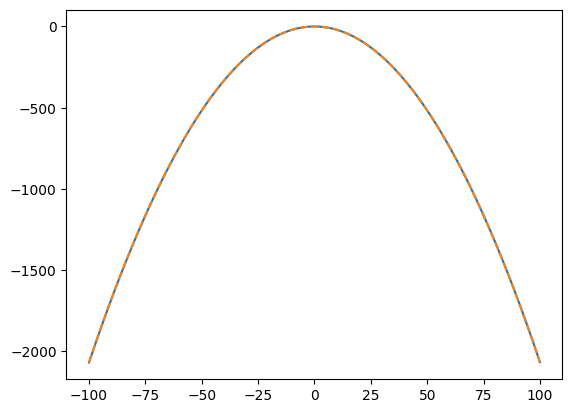

In [14]:
plt.plot(test_param_dev, ll_int)
plt.plot(test_param_dev, ll_dir, linestyle="--")